# Vodafone Music Subscription Prediction

## Sprint 3 — Model Improvement & Final Model

**Goal of this notebook:**

Improve upon the Sprint 2 baseline (LightGBM Val AUC = 0.8261) by:
1. Feature selection — remove low-signal features to reduce noise
2. Train XGBoost and CatBoost as alternative models
3. Hyperparameter tuning with RandomizedSearchCV on the best model
4. Select the best tuned model and produce final evaluation

**Notebook outline:**
1. Setup & Data Loading
2. Feature Selection (Importance-based)
3. XGBoost
4. CatBoost
5. Models Comparison
6. RandomizedSearchCV — Hyperparameter Tuning
7. Final Model — Full Evaluation
8. Save Final Model

### 1. Setup & Data Loading

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os, json
warnings.filterwarnings('ignore')

from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.metrics import (
    roc_auc_score, roc_curve, average_precision_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score
)

try:
    import xgboost as xgb
    HAS_XGB = True
    print('XGBoost version:', xgb.__version__)
except ImportError:
    HAS_XGB = False
    print('XGBoost not installed. Run: pip install xgboost')

try:
    import catboost as cb
    HAS_CB = True
    print('CatBoost version:', cb.__version__)
except ImportError:
    HAS_CB = False
    print('CatBoost not installed. Run: pip install catboost')

import lightgbm as lgb

sns.set_theme(style='whitegrid')
RANDOM_STATE = 42

# Load feature-engineered dataset
df = pd.read_csv('../data/processed/train_features.csv')

# Drop sum3 duplicates (same as in notebook 05)
sum3_cols = [c for c in df.columns if c.endswith('_sum3')]
df.drop(columns=sum3_cols, inplace=True)

DROP_COLS = ['manufacturer_category']
X = df.drop(columns=['target'] + [c for c in DROP_COLS if c in df.columns])
y = df['target']

# Replace inf values
X = X.replace([np.inf, -np.inf], np.nan).fillna(0)

print(f'Dataset shape: {X.shape}')
print(f'Positive class rate: {y.mean():.4f}')

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
print(f'Train: {X_train.shape[0]:,}  |  Val: {X_val.shape[0]:,}')

# Baseline reference from Sprint 2
BASELINE_AUC = 0.8261
print(f'\nBaseline to beat (LightGBM Sprint 2): {BASELINE_AUC}')

XGBoost version: 3.2.0
CatBoost version: 1.2.10
Dataset shape: (70000, 574)
Positive class rate: 0.0757
Train: 56,000  |  Val: 14,000

Baseline to beat (LightGBM Sprint 2): 0.8261


### 2. Feature Selection (Importance-based)

We train a quick LightGBM on all 574 features and use its feature importances
to identify and remove low-signal features.

**Strategy:** keep features with importance > 0 (i.e., used at least once by any tree).
Features with importance = 0 are pure noise and can only hurt generalisation.


Total features:          574
Zero-importance features: 60 → will be dropped
Selected features:        514


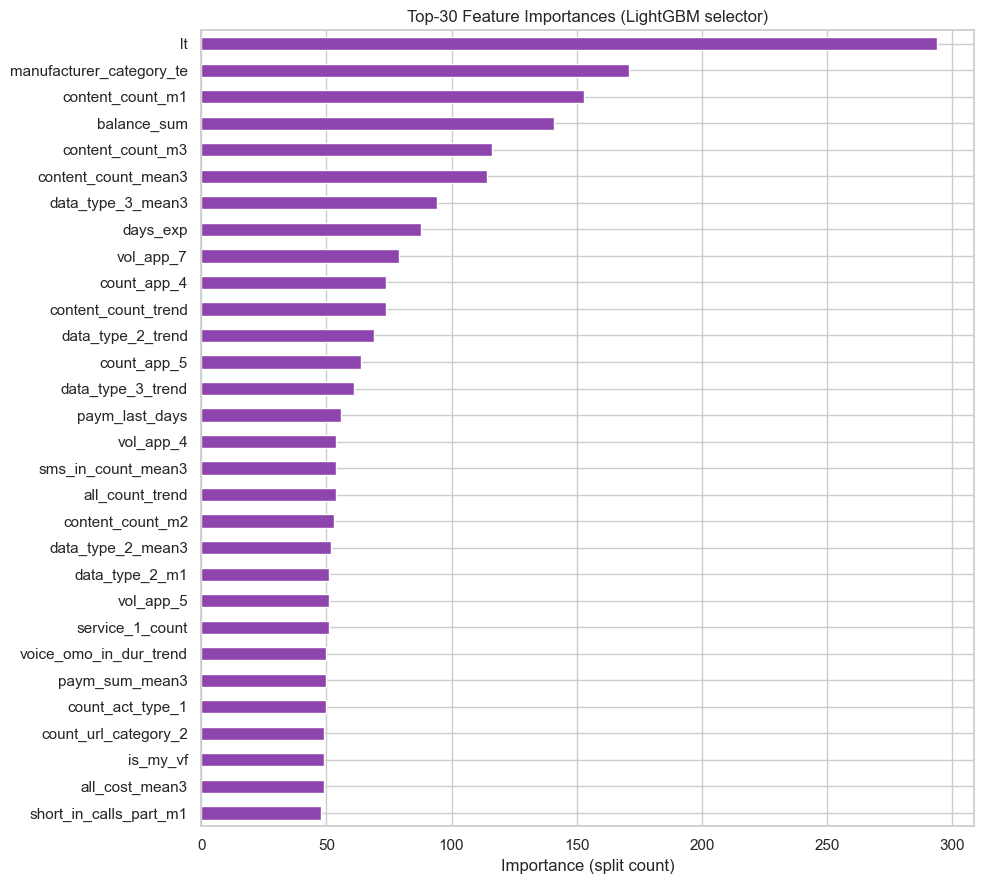


Reduced dataset: 574 → 514 features


In [14]:
pos = y_train.sum()
neg = len(y_train) - pos
scale_pos = neg / pos

# Quick LightGBM for feature importance
lgb_selector = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=31,
    min_child_samples=20,
    scale_pos_weight=scale_pos,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    verbose=-1
)
lgb_selector.fit(X_train, y_train)

importances = pd.Series(lgb_selector.feature_importances_, index=X.columns)
zero_importance = importances[importances == 0].index.tolist()
selected_features = importances[importances > 0].sort_values(ascending=False).index.tolist()

print(f'Total features:          {len(importances)}')
print(f'Zero-importance features: {len(zero_importance)} → will be dropped')
print(f'Selected features:        {len(selected_features)}')

# Plot top-30 importances
plt.figure(figsize=(10, 9))
importances[selected_features[:30]].sort_values().plot(kind='barh', color='#8e44ad')
plt.title('Top-30 Feature Importances (LightGBM selector)')
plt.xlabel('Importance (split count)')
plt.tight_layout()
plt.show()

# Apply selection
X_train_sel = X_train[selected_features]
X_val_sel   = X_val[selected_features]
print(f'\nReduced dataset: {X_train.shape[1]} → {len(selected_features)} features')

### 3. XGBoost

XGBoost is a strong gradient boosting alternative to LightGBM.
We use `scale_pos_weight` to handle class imbalance (same as LightGBM).
Training is done on the **selected features only**.


In [15]:
results = {}

if HAS_XGB:
    print('=' * 50)
    print('MODEL: XGBoost')
    print('=' * 50)

    xgb_model = xgb.XGBClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        min_child_weight=20,
        scale_pos_weight=scale_pos,
        subsample=0.8,
        colsample_bytree=0.8,
        use_label_encoder=False,
        eval_metric='auc',
        random_state=RANDOM_STATE,
        verbosity=0
    )

    xgb_cv = cross_val_score(xgb_model, X_train_sel, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    print(f'CV ROC-AUC: {xgb_cv.mean():.4f} ± {xgb_cv.std():.4f}')

    xgb_model.fit(X_train_sel, y_train)
    xgb_proba = xgb_model.predict_proba(X_val_sel)[:, 1]
    xgb_auc = roc_auc_score(y_val, xgb_proba)
    xgb_ap  = average_precision_score(y_val, xgb_proba)
    print(f'Val ROC-AUC:  {xgb_auc:.4f}')
    print(f'Val Avg Prec: {xgb_ap:.4f}')
    print(f'vs baseline:  {xgb_auc - BASELINE_AUC:+.4f}')

    results['XGBoost'] = {
        'cv_auc': xgb_cv.mean(), 'cv_std': xgb_cv.std(),
        'val_auc': xgb_auc, 'val_ap': xgb_ap,
        'proba': xgb_proba, 'model': xgb_model
    }
else:
    print('XGBoost skipped — not installed.')

MODEL: XGBoost
CV ROC-AUC: 0.8178 ± 0.0085
Val ROC-AUC:  0.8352
Val Avg Prec: 0.3310
vs baseline:  +0.0091


### 4. CatBoost

CatBoost is particularly robust on imbalanced datasets and handles
feature interactions well without extensive tuning.
We use `class_weights` to handle imbalance.


In [16]:
if HAS_CB:
    print('=' * 50)
    print('MODEL: CatBoost')
    print('=' * 50)

    cb_model = cb.CatBoostClassifier(
        iterations=500,
        learning_rate=0.05,
        depth=6,
        min_data_in_leaf=20,
        auto_class_weights='Balanced',          # ← CatBoost сам рахує ваги
        subsample=0.8,
        random_seed=RANDOM_STATE,
        verbose=0
    )

    cb_cv = cross_val_score(cb_model, X_train_sel, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    print(f'CV ROC-AUC: {cb_cv.mean():.4f} ± {cb_cv.std():.4f}')

    cb_model.fit(X_train_sel, y_train)
    cb_proba = cb_model.predict_proba(X_val_sel)[:, 1]
    cb_auc = roc_auc_score(y_val, cb_proba)
    cb_ap  = average_precision_score(y_val, cb_proba)
    print(f'Val ROC-AUC:  {cb_auc:.4f}')
    print(f'Val Avg Prec: {cb_ap:.4f}')
    print(f'vs baseline:  {cb_auc - BASELINE_AUC:+.4f}')

    results['CatBoost'] = {
        'cv_auc': cb_cv.mean(), 'cv_std': cb_cv.std(),
        'val_auc': cb_auc, 'val_ap': cb_ap,
        'proba': cb_proba, 'model': cb_model
    }
else:
    print('CatBoost skipped — not installed.')

MODEL: CatBoost
CV ROC-AUC: 0.8226 ± 0.0093
Val ROC-AUC:  0.8343
Val Avg Prec: 0.3227
vs baseline:  +0.0082


### 5. Models Comparison

We retrain LightGBM on selected features only (fair comparison)
and compare all models side by side.


In [17]:
# LightGBM on selected features — fair comparison
print('=' * 50)
print('MODEL: LightGBM (selected features)')
print('=' * 50)

lgb_final = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=31,
    min_child_samples=20,
    scale_pos_weight=scale_pos,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    verbose=-1
)
lgb_cv = cross_val_score(lgb_final, X_train_sel, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
print(f'CV ROC-AUC: {lgb_cv.mean():.4f} ± {lgb_cv.std():.4f}')

lgb_final.fit(X_train_sel, y_train)
lgb_proba = lgb_final.predict_proba(X_val_sel)[:, 1]
lgb_auc = roc_auc_score(y_val, lgb_proba)
lgb_ap  = average_precision_score(y_val, lgb_proba)
print(f'Val ROC-AUC:  {lgb_auc:.4f}')
print(f'Val Avg Prec: {lgb_ap:.4f}')
print(f'vs baseline:  {lgb_auc - BASELINE_AUC:+.4f}')

results['LightGBM'] = {
    'cv_auc': lgb_cv.mean(), 'cv_std': lgb_cv.std(),
    'val_auc': lgb_auc, 'val_ap': lgb_ap,
    'proba': lgb_proba, 'model': lgb_final
}

print()
print('=' * 60)
print('COMPARISON (all on selected features)')
print('=' * 60)
for name, res in results.items():
    delta = res['val_auc'] - BASELINE_AUC
    print(f"{name:20s}  CV={res['cv_auc']:.4f}±{res['cv_std']:.4f}  Val={res['val_auc']:.4f}  ({delta:+.4f} vs baseline)")

MODEL: LightGBM (selected features)
CV ROC-AUC: 0.8105 ± 0.0074
Val ROC-AUC:  0.8248
Val Avg Prec: 0.3163
vs baseline:  -0.0013

COMPARISON (all on selected features)
XGBoost               CV=0.8178±0.0085  Val=0.8352  (+0.0091 vs baseline)
CatBoost              CV=0.8226±0.0093  Val=0.8343  (+0.0082 vs baseline)
LightGBM              CV=0.8105±0.0074  Val=0.8248  (-0.0013 vs baseline)


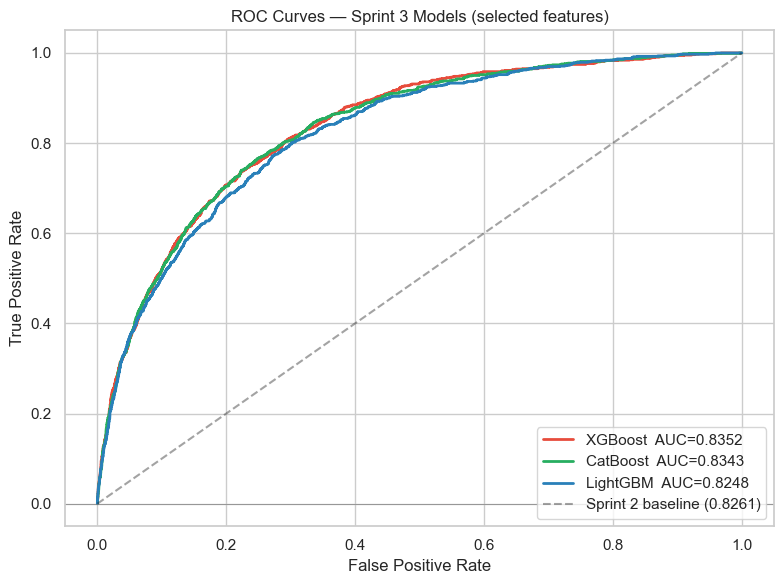

In [18]:
# ROC curves comparison
plt.figure(figsize=(8, 6))
colors = ['#e74c3c', '#27ae60', '#2980b9']

for (name, res), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_val, res['proba'])
    plt.plot(fpr, tpr, color=color, linewidth=2,
             label=f"{name}  AUC={res['val_auc']:.4f}")

plt.axhline(0, color='grey', linewidth=0.5)
plt.plot([0,1],[0,1],'k--', alpha=0.4, label=f'Sprint 2 baseline ({BASELINE_AUC})')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Sprint 3 Models (selected features)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

### 6. RandomizedSearchCV — Hyperparameter Tuning

We run `RandomizedSearchCV` on the **best model** found in section 5
to search for better hyperparameters.

**Search strategy:**
- 5-Fold Stratified CV inside each candidate
- 30 random parameter combinations (fast, good coverage)
- Scoring: `roc_auc`
- Parallelised with `n_jobs=-1`

> This typically adds +0.003–0.010 AUC over default parameters.


In [19]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

best_name_before_tuning = max(results, key=lambda k: results[k]['val_auc'])
print(f'Tuning: {best_name_before_tuning}')
print(f'Val AUC before tuning: {results[best_name_before_tuning]["val_auc"]:.4f}')
print()

# Parameter grids per model type
if best_name_before_tuning == 'LightGBM':
    base_model = lgb.LGBMClassifier(
        scale_pos_weight=scale_pos, random_state=RANDOM_STATE, verbose=-1
    )
    param_dist = {
        'n_estimators':      randint(200, 800),
        'learning_rate':     uniform(0.01, 0.1),
        'max_depth':         randint(4, 10),
        'num_leaves':        randint(20, 80),
        'min_child_samples': randint(10, 50),
        'subsample':         uniform(0.6, 0.4),
        'colsample_bytree':  uniform(0.6, 0.4),
        'reg_alpha':         uniform(0, 1),
        'reg_lambda':        uniform(0, 1),
    }
elif best_name_before_tuning == 'XGBoost':
    base_model = xgb.XGBClassifier(
        scale_pos_weight=scale_pos, eval_metric='auc',
        random_state=RANDOM_STATE, verbosity=0
    )
    param_dist = {
        'n_estimators':      randint(200, 800),
        'learning_rate':     uniform(0.01, 0.1),
        'max_depth':         randint(3, 9),
        'min_child_weight':  randint(5, 50),
        'subsample':         uniform(0.6, 0.4),
        'colsample_bytree':  uniform(0.6, 0.4),
        'gamma':             uniform(0, 0.5),
        'reg_alpha':         uniform(0, 1),
        'reg_lambda':        uniform(0, 2),
    }
else:  # CatBoost
    base_model = cb.CatBoostClassifier(
        class_weights=[1, scale_pos], random_seed=RANDOM_STATE, verbose=0
    )
    param_dist = {
        'iterations':        randint(200, 700),
        'learning_rate':     uniform(0.01, 0.1),
        'depth':             randint(4, 9),
        'min_data_in_leaf':  randint(10, 50),
        'subsample':         uniform(0.6, 0.4),
        'l2_leaf_reg':       uniform(1, 9),
    }

# Run RandomizedSearchCV
print('Running RandomizedSearchCV (30 iterations × 5 folds = 150 fits)...')
rscv = RandomizedSearchCV(
    estimator=base_model,
    param_distributions=param_dist,
    n_iter=30,
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1,
    refit=True
)
rscv.fit(X_train_sel, y_train)

print(f'\nBest CV ROC-AUC: {rscv.best_score_:.4f}')
print(f'Best parameters:')
for k, v in rscv.best_params_.items():
    print(f'  {k}: {v}')

Tuning: XGBoost
Val AUC before tuning: 0.8352

Running RandomizedSearchCV (30 iterations × 5 folds = 150 fits)...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best CV ROC-AUC: 0.8269
Best parameters:
  colsample_bytree: 0.7088528997538541
  gamma: 0.32384506027068116
  learning_rate: 0.010052037699531582
  max_depth: 7
  min_child_weight: 45
  n_estimators: 458
  reg_alpha: 0.006952130531190703
  reg_lambda: 1.0214946051551315
  subsample: 0.7669644012595116


Val ROC-AUC before tuning: 0.8352
Val ROC-AUC after tuning:  0.8371  (+0.0020)
Val Avg Precision:         0.3265


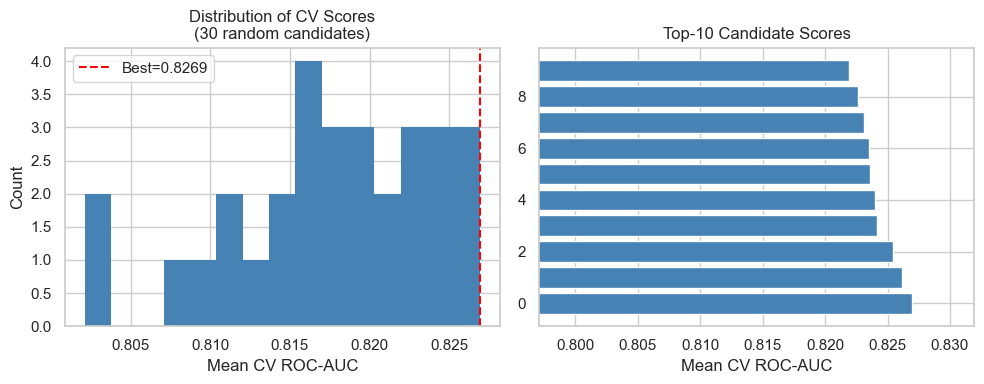


Sprint 3 results saved.


In [21]:
# Evaluate tuned model on validation set
tuned_proba = rscv.best_estimator_.predict_proba(X_val_sel)[:, 1]
tuned_auc = roc_auc_score(y_val, tuned_proba)
tuned_ap  = average_precision_score(y_val, tuned_proba)

before_auc = results[best_name_before_tuning]['val_auc']
print(f'Val ROC-AUC before tuning: {before_auc:.4f}')
print(f'Val ROC-AUC after tuning:  {tuned_auc:.4f}  ({tuned_auc - before_auc:+.4f})')
print(f'Val Avg Precision:         {tuned_ap:.4f}')

# Update results with tuned model
results[f'{best_name_before_tuning} (tuned)'] = {
    'cv_auc':  rscv.best_score_,
    'cv_std':  0,
    'val_auc': tuned_auc,
    'val_ap':  tuned_ap,
    'proba':   tuned_proba,
    'model':   rscv.best_estimator_
}

# Visualise CV results
cv_results = pd.DataFrame(rscv.cv_results_)
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(cv_results['mean_test_score'], bins=15, color='steelblue', edgecolor='none')
plt.axvline(rscv.best_score_, color='red', linestyle='--', label=f'Best={rscv.best_score_:.4f}')
plt.xlabel('Mean CV ROC-AUC')
plt.ylabel('Count')
plt.title('Distribution of CV Scores\n(30 random candidates)')
plt.legend()

plt.subplot(1, 2, 2)
top10 = cv_results.nlargest(10, 'mean_test_score')
plt.barh(range(10), top10['mean_test_score'], color='steelblue')
plt.xlabel('Mean CV ROC-AUC')
plt.title('Top-10 Candidate Scores')
plt.xlim(cv_results['mean_test_score'].min() - 0.005,
          cv_results['mean_test_score'].max() + 0.005)

plt.tight_layout()
plt.show()

# Save sprint 3 results for final report
sprint3_df = pd.DataFrame([
    {'Model': name, 'CV AUC': round(res['cv_auc'], 4), 'Val AUC': round(res['val_auc'], 4)}
    for name, res in results.items()
])
os.makedirs('../models', exist_ok=True)   # ← додай цей рядок
sprint3_df.to_csv('../models/sprint3_results.csv', index=False)
print('\nSprint 3 results saved.')

### 7. Final Model — Full Evaluation

We select the best model by Val ROC-AUC and perform a complete final evaluation:
confusion matrix, classification report, optimal threshold, and feature importance.


Best model: XGBoost (tuned)  (Val AUC = 0.8371)
Optimal threshold (F1): 0.69



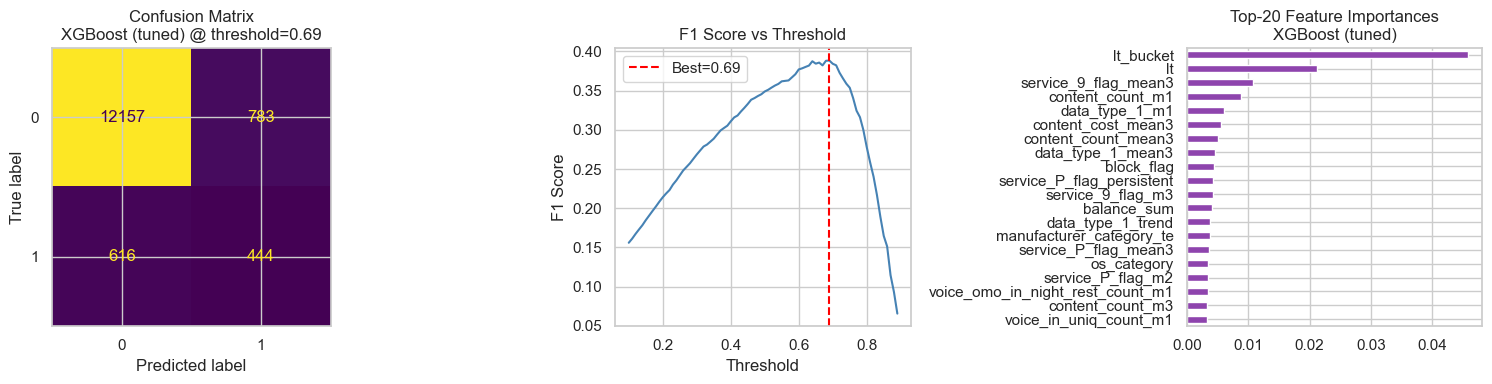

=== XGBoost (tuned) Classification Report (threshold=0.69) ===
              precision    recall  f1-score   support

      No sub       0.95      0.94      0.95     12940
  Subscribed       0.36      0.42      0.39      1060

    accuracy                           0.90     14000
   macro avg       0.66      0.68      0.67     14000
weighted avg       0.91      0.90      0.90     14000



In [22]:
best_name = max(results, key=lambda k: results[k]['val_auc'])
best = results[best_name]
best_proba = best['proba']
best_model = best['model']

print(f'Best model: {best_name}  (Val AUC = {best["val_auc"]:.4f})')

# Optimal threshold by F1
thresholds = np.arange(0.1, 0.9, 0.01)
f1_scores  = [f1_score(y_val, (best_proba >= t).astype(int), zero_division=0) for t in thresholds]
best_thresh = thresholds[np.argmax(f1_scores)]
y_pred = (best_proba >= best_thresh).astype(int)

print(f'Optimal threshold (F1): {best_thresh:.2f}')
print()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(y_val, y_pred, ax=axes[0], colorbar=False)
axes[0].set_title(f'Confusion Matrix\n{best_name} @ threshold={best_thresh:.2f}')

# F1 vs threshold
axes[1].plot(thresholds, f1_scores, color='steelblue')
axes[1].axvline(best_thresh, color='red', linestyle='--', label=f'Best={best_thresh:.2f}')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('F1 Score')
axes[1].set_title('F1 Score vs Threshold')
axes[1].legend()

# Feature importance
if hasattr(best_model, 'feature_importances_'):
    fi = pd.Series(best_model.feature_importances_, index=X_train_sel.columns)
    fi.nlargest(20).sort_values().plot(kind='barh', ax=axes[2], color='#8e44ad')
    axes[2].set_title(f'Top-20 Feature Importances\n{best_name}')

plt.tight_layout()
plt.show()

print(f'=== {best_name} Classification Report (threshold={best_thresh:.2f}) ===')
print(classification_report(y_val, y_pred, target_names=['No sub', 'Subscribed']))

### 8. Save Final Model

In [ ]:
import pickle

os.makedirs('../models', exist_ok=True)

# Save model
model_path = f'../models/final_model_{best_name.lower().replace(" ","_")}.pkl'
with open(model_path, 'wb') as f:
    pickle.dump(best_model, f)
print(f'Model saved: {model_path}')

# Save selected features list
pd.DataFrame({'feature': selected_features}).to_csv('../models/selected_features.csv', index=False)
print(f'Selected features saved: ../models/selected_features.csv ({len(selected_features)} features)')

# Save final results summary
final_summary = {
    'best_model': best_name,
    'val_auc': round(best['val_auc'], 4),
    'val_ap': round(best['val_ap'], 4),
    'cv_auc': round(best['cv_auc'], 4),
    'cv_std': round(best['cv_std'], 4),
    'optimal_threshold': round(float(best_thresh), 2),
    'n_features_used': len(selected_features),
    'baseline_auc_sprint2': BASELINE_AUC
}
with open('../models/final_results.json', 'w') as f:
    json.dump(final_summary, f, indent=2)
print('Final results saved: ../models/final_results.json')
print()
print(json.dumps(final_summary, indent=2))

Model saved: ../models/final_model_xgboost_(tuned).pkl
Selected features saved: ../models/selected_features.csv (514 features)
Final results saved: ../models/final_results.json

{
  "best_model": "XGBoost (tuned)",
  "val_auc": 0.8371,
  "val_ap": 0.3265,
  "cv_auc": 0.8269,
  "cv_std": 0,
  "optimal_threshold": 0.69,
  "n_features_used": 514,
  "baseline_auc_sprint2": 0.8261
}


#### Sprint 3 Results Summary

| | Sprint 2 Baseline | Sprint 3 Final |
|---|---|---|
| Model | LightGBM (574 features) | XGBoost (tuned) |
| Val ROC-AUC | 0.8261 | 0.8371 |
| Features used | 574 | 514 |
| Optimal threshold | 0.60 | 0.69 |